# Week 06: Stats for Business: Is the Price Right?

You just joined the pricing team at a car-listing marketplace. Your manager has a few questions and one rule: **every claim needs a number, and every number needs a reason to trust it.**

**Data:** `cars.csv`: about 12,000 car trims (1990–2017) with specs and sticker price (MSRP). Source: [Car Features and MSRP (Kaggle)](https://www.kaggle.com/datasets/CooperUnion/cardataset). It's real data, so it's messy.

**What you'll practice** (all from this week's lecture):
- Cleaning before describing
- Mean vs median, skew, log transforms
- z-scores
- Bootstrap confidence intervals
- One- and two-sample tests, and picking the right one
- Confounding, and significant vs important

**How to answer:** Fill in the code cells, then write 1–3 sentences in each **Answer:** cell. Code without an interpretation is only half the job.

Plan for about 2–3 hours. 🚀 questions are optional stretch.

## Setup

In [1]:
# run this first if you dont have them installed in your env
!pip install pandas numpy matplotlib scipy


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", None)
rng = np.random.default_rng(42)  # use rng for all random sampling so your results are reproducible

df = pd.read_csv("../data/cars.csv")
print(df.shape)
df.head()

(11914, 15)


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,18,3916,34500


---
## Part 1: Can you trust this data?

### Q1. Find the problems before you average anything

This dataset has **at least five** real problems. Find them, fix or flag each one, and build a cleaned DataFrame called `clean`. You'll use `clean` for the rest of the notebook.

Use your Week 02 cleaning checklist. Some nudges, in no particular order:
- Count things twice.
- The most common value in a column can be more suspicious than the largest one.
- Would you print every max value in a sales brochure?
- Missing values usually have a reason. *Who* is missing?
- Is every number in a column measured in the same unit?
- Does every column vary at the level you'd expect?
- Not everything weird is wrong.

For each problem, decide: **drop it, set it to NaN, flag it, or leave it**. Dropping whole rows is the last resort, because a row with a bad price may still have a good MPG.

In [3]:
# Explore here. Add as many cells as you need.
# Useful: .duplicated(), .value_counts(), .describe(), .isna().sum(), .nlargest(), .groupby(...).nunique()
df.duplicated().sum()

np.int64(720)

In [4]:
print(df.isna().sum())
print(f"Rows with missing values: {len(df) - len(df.dropna())}")

Make                  0
Model                 0
Year                  0
Engine Fuel Type      3
Engine HP            69
Engine Cylinders     30
Transmission Type     0
Driven_Wheels         0
Number of Doors       6
Vehicle Size          0
Vehicle Style         0
highway MPG           0
city mpg              0
Popularity            0
MSRP                  0
dtype: int64
Rows with missing values: 102


In [5]:
df["MSRP"].value_counts().head()

MSRP
2000     1036
25995      19
29995      19
20995      16
27995      16
Name: count, dtype: int64

In [6]:
df.loc[df["MSRP"] == 2000, "Year"].agg(["min", "max"])

min    1990
max    2000
Name: Year, dtype: int64

In [7]:
df[df["Engine HP"].isna()]["Engine Fuel Type"].value_counts(dropna=False)

Engine Fuel Type
electric                            44
regular unleaded                    14
flex-fuel (unleaded/natural gas)     6
premium unleaded (recommended)       4
diesel                               1
Name: count, dtype: int64

In [8]:
df.nlargest(3, "highway MPG")

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
1119,Audi,A6,2017,premium unleaded (recommended),252.0,4.0,AUTOMATED_MANUAL,front wheel drive,4.0,Midsize,Sedan,354,24,3105,51600
5790,BMW,i3,2015,electric,170.0,0.0,DIRECT_DRIVE,rear wheel drive,4.0,Compact,4dr Hatchback,111,137,3916,42400
5791,BMW,i3,2016,electric,170.0,0.0,DIRECT_DRIVE,rear wheel drive,4.0,Compact,4dr Hatchback,111,137,3916,42400


In [9]:
df.groupby("Engine Fuel Type")["highway MPG"].describe()

,count,mean,std,min,25%,50%,75%,max
Engine Fuel Type,,,,,,,,
diesel,154.0,36.564935,6.743601,20.0,30.0,39.0,42.00,46.0
electric,66.0,99.590909,9.026418,74.0,97.0,101.0,105.00,111.0
flex-fuel (premium unleaded recommended/E85),26.0,25.346154,6.235013,18.0,18.0,27.5,31.25,33.0
flex-fuel (premium unleaded required/E85),54.0,19.925926,1.746715,17.0,19.0,19.0,20.75,23.0
flex-fuel (unleaded/E85),899.0,22.629588,4.632803,15.0,19.0,22.0,25.00,40.0
flex-fuel (unleaded/natural gas),6.0,25.000000,0.000000,25.0,25.0,25.0,25.00,25.0
natural gas,2.0,38.000000,0.000000,38.0,38.0,38.0,38.00,38.0
premium unleaded (recommended),1523.0,28.672357,9.363849,16.0,25.0,29.0,31.00,354.0
premium unleaded (required),2009.0,23.896964,5.125403,12.0,20.0,24.0,27.00,48.0


In [10]:
df["Transmission Type"].value_counts()

Transmission Type
AUTOMATIC           8266
MANUAL              2935
AUTOMATED_MANUAL     626
DIRECT_DRIVE          68
UNKNOWN               19
Name: count, dtype: int64

In [11]:
df.groupby("Make")["Popularity"].nunique().value_counts()

Popularity
1    48
Name: count, dtype: int64

**Cleaning log:** fill in one row per problem.

| # | Problem | How I found it | Rows affected | What I did | Why |
|---|---|---|---|---|---|
| 1 | Exact duplicate rows | `.duplicated().sum()` | 720 | Dropped exact duplicates, leaving 11,194 rows | Avoid counting the same record twice. |
| 2 | Suspicious $2,000 price floor | `.value_counts()` shows 1,036 raw rows at $2,000; the next price occurs 19 times, and all $2,000 rows are from 1990–2000 | 747 after removing duplicates | Set these prices to NaN; kept the rows | The pileup at the minimum suggests a price floor, so these values are unreliable for price calculations. |
| 3 | Electric fuel economy mixed with MPG | Electric rows have highway values of 74–111 in the MPG column | 66 | Set electric highway and city values to NaN; kept the rows | Electric energy-equivalent mileage should not be averaged with miles per gallon of fuel. |
| 4 | Suspicious highway MPG | `.nlargest()` shows an Audi A6 at 354 highway MPG but 24 city MPG | 1 | Set its highway MPG to NaN | It is far beyond the other values; the correct value is unknown. |
| 5 | Missing values and UNKNOWN transmission | `.isna().sum()` finds 69 missing HP, 30 cylinders, 6 doors, and 3 fuel types; 44 missing HP values are on electric cars | 108 missing entries in 102 raw rows; 12 UNKNOWN transmissions after removing duplicates | Left missing values as NaN and replaced UNKNOWN with NaN | Missingness is concentrated in electric-car HP; guessing values or dropping entire rows would lose useful data. |
| 6 | Popularity repeats at the make level | `.groupby("Make")["Popularity"].nunique()` is 1 for all 48 makes | All 11,914 raw rows | Left unchanged; flagged here as a make-level measure | It does not measure the popularity of individual models or trims. |


In [12]:
# Build your cleaned DataFrame. Start from a copy so df stays untouched.
clean = df.copy()
clean.columns = clean.columns.str.strip().str.lower().str.replace(" ", "_")  # freebie: snake_case names

In [13]:
clean = clean.drop_duplicates()
clean.loc[clean["msrp"] == 2000, "msrp"] = np.nan
clean.loc[clean["transmission_type"] == "UNKNOWN", "transmission_type"] = np.nan
electric = clean["engine_fuel_type"] == "electric"
clean.loc[electric, ["highway_mpg", "city_mpg"]] = np.nan
clean.loc[clean["highway_mpg"] == 354, "highway_mpg"] = np.nan

In [14]:
# Checkpoint: run this before moving on.
print(clean.shape)
print(clean.isna().sum()[clean.isna().sum() > 0])
# Fewer than ~10,000 rows? You probably dropped too much. Go back and use NaN or a flag instead.

(11194, 15)
engine_fuel_type       3
engine_hp             69
engine_cylinders      30
transmission_type     12
number_of_doors        6
highway_mpg           67
city_mpg              66
msrp                 747
dtype: int64


---
## Part 2: Describe

### Q2. What does a "typical" car cost?

Your manager wants one number for "typical price" on the homepage.

a) Compute the mean and median MSRP. Which is bigger, and why?

b) Plot a histogram of MSRP, then a histogram of `np.log10(msrp)`. Describe each shape in a few words.

c) What percent of cars cost more than the mean?

d) Which number belongs on the homepage? Why?

Mean MSRP: $44,789
Median MSRP: $31,870


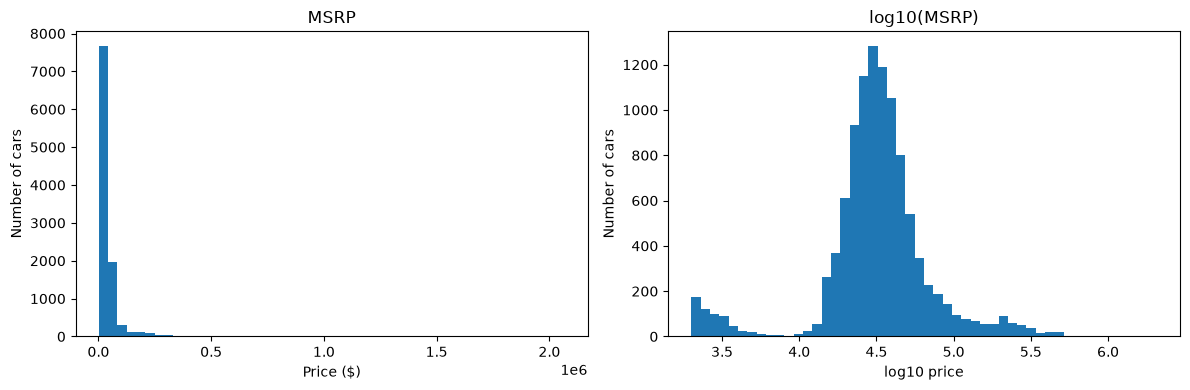

Share above mean: 24.4%


In [15]:
# a) mean and median
msrp = clean["msrp"].dropna()
print(f"Mean MSRP: ${msrp.mean():,.0f}")
print(f"Median MSRP: ${msrp.median():,.0f}")

# b) two histograms side by side (plt.subplots(1, 2))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(msrp, bins=50)
axes[0].set_title("MSRP")
axes[0].set_xlabel("Price ($)")
axes[0].set_ylabel("Number of cars")
axes[1].hist(np.log10(msrp), bins=50)
axes[1].set_title("log10(MSRP)")
axes[1].set_xlabel("log10 price")
axes[1].set_ylabel("Number of cars")
plt.tight_layout()
plt.show()

# c) share of cars above the mean
print(f"Share above mean: {(msrp > msrp.mean()).mean():.1%}")


**Answer:** The mean ($44,789) exceeds the median ($31,870) because expensive cars pull the mean upward. MSRP is strongly right-skewed; log10(MSRP) is more balanced, with a smaller cluster of low prices on the left. Only 24.4% of cars with usable prices exceed the mean, so I would use the median on the homepage because it better represents a typical price.

### Q3. Fuel-efficient *for its size*?

Two 2017 cars:
- **Honda Civic** (Compact): 42 highway MPG
- **Volvo S90** (Large): 34 highway MPG

The Civic wins on raw MPG, but large cars are heavier. Which one is more impressive *for its class*?

a) For 2017 cars (only the MPG values you trust after Q1), compute the mean and standard deviation of highway MPG for each `vehicle_size`.

b) Compute each car's z-score within its own size class.

c) Which is more fuel-efficient for its class? How unusual is each one?

In [16]:
# a) mean and std of highway_mpg by vehicle_size, 2017 only
mpg_2017 = clean[clean["year"] == 2017].dropna(subset=["highway_mpg"])
size_stats = mpg_2017.groupby("vehicle_size")["highway_mpg"].agg(["mean", "std"])
print(size_stats)

# b) z = (value - class mean) / class std
civic_z = (42 - size_stats.loc["Compact", "mean"]) / size_stats.loc["Compact", "std"]
s90_z = (34 - size_stats.loc["Large", "mean"]) / size_stats.loc["Large", "std"]
print(f"Civic z-score: {civic_z:.2f}")
print(f"S90 z-score: {s90_z:.2f}")

                   mean       std
vehicle_size                     
Compact       30.880157  6.045381
Large         22.991453  3.491184
Midsize       29.410658  5.452292
Civic z-score: 1.84
S90 z-score: 3.15


**Answer:** The Civic is 1.84 standard deviations above the Compact mean, while the S90 is 3.15 standard deviations above the Large mean. The S90 is more unusual and more fuel-efficient relative to its class, despite having lower raw MPG.

---
## Part 3: Uncertainty

### Q4. How sure are we about the median price?

The 2017 cars are one snapshot of the market. With a slightly different set of cars, the median would move. A bootstrap shows how much.

a) Compute the median MSRP of 2017 cars.

b) Bootstrap it: resample the 2017 prices **with replacement** 5,000 times and take the median each time. Plot the 5,000 medians and report the 95% interval (2.5th and 97.5th percentiles).

c) Repeat for 2017 cars from **one make** with fewer than 50 cars that year (your choice). Is the interval wider or narrower? Why?

d) Explain the interval from (b) in one sentence a manager would understand.

Median 2017 MSRP: $36,738


95% interval: $35,940 to $37,683


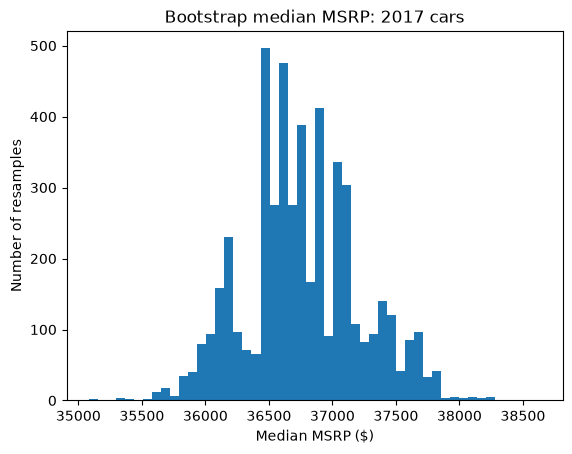

Lincoln 2017 cars: 46
Lincoln median MSRP: $46,060


95% interval: $41,648 to $49,025
Width, all 2017: $1,743; Lincoln: $7,378


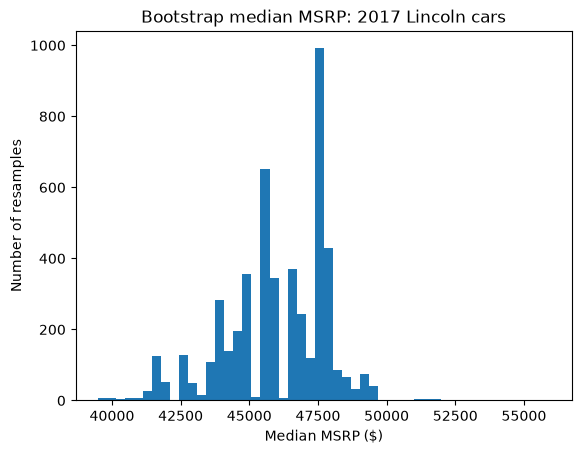

In [17]:
def bootstrap_median(values, n_boot=5000):
    """Return an array of n_boot bootstrap medians."""
    # hint: rng.choice(values, size=len(values), replace=True)
    medians = []
    for _ in range(n_boot):
        sample = rng.choice(values, size=len(values), replace=True)
        medians.append(np.median(sample))
    return np.array(medians)

# a, b)
prices_2017 = clean.loc[clean["year"] == 2017, "msrp"].dropna()
print(f"Median 2017 MSRP: ${prices_2017.median():,.0f}")
medians = bootstrap_median(prices_2017.values)
low, high = np.percentile(medians, [2.5, 97.5])
print(f"95% interval: ${low:,.0f} to ${high:,.0f}")
plt.hist(medians, bins=50)
plt.title("Bootstrap median MSRP: 2017 cars")
plt.xlabel("Median MSRP ($)")
plt.ylabel("Number of resamples")
plt.show()

# c)
lincoln_2017 = clean.loc[(clean["year"] == 2017) & (clean["make"] == "Lincoln"), "msrp"].dropna()
print(f"Lincoln 2017 cars: {len(lincoln_2017)}")
print(f"Lincoln median MSRP: ${lincoln_2017.median():,.0f}")
lincoln_medians = bootstrap_median(lincoln_2017.values)
lincoln_low, lincoln_high = np.percentile(lincoln_medians, [2.5, 97.5])
print(f"95% interval: ${lincoln_low:,.0f} to ${lincoln_high:,.0f}")
print(f"Width, all 2017: ${high - low:,.0f}; Lincoln: ${lincoln_high - lincoln_low:,.0f}")
plt.hist(lincoln_medians, bins=50)
plt.title("Bootstrap median MSRP: 2017 Lincoln cars")
plt.xlabel("Median MSRP ($)")
plt.ylabel("Number of resamples")
plt.show()


**Answer:** The 2017 median is $36,738, with a 95% bootstrap interval of $35,940–$37,683. Lincoln has 46 cars and a wider interval ($41,648–$49,025); its smaller sample leaves more uncertainty about the median, though the spread of prices also matters. For the manager, we are 95% confident that the median price for the market represented by these 2017 cars is about $35,940–$37,683.

---
## Part 4: Testing

### Q5. Can marketing say "our 2017 compacts average over 30 MPG"?

a) Write H₀ and Hₐ. One-sided or two-sided? Why?

b) How many cars are in the sample, and what does the distribution look like? Is a t-test reasonable here?

c) Run a one-sample t-test at α = 0.05 (`stats.ttest_1samp(..., alternative="greater")`). State the conclusion in plain English.

d) **Independence check.** Tests assume each row is an independent observation. Count how many rows each `make` + `model` has in this sample. Then average to one row per model and rerun the test. What changed, and which version do you trust more?

n = 509, mean = 30.88


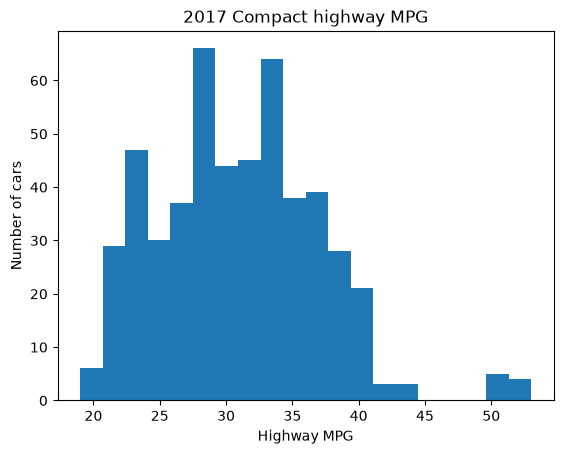

t-statistic: 3.2847
p-value: 0.0005
make       model    
Toyota     Tacoma       27
Chevrolet  Corvette     24
Nissan     Frontier     22
           370Z         17
Porsche    911          14
                        ..
BMW        M2            1
Lexus      CT 200h       1
Lotus      Evora 400     1
Ford       Focus ST      1
           Focus RS      1
Length: 85, dtype: int64
Models: 85, mean MPG: 31.69
t-statistic: 2.5773
p-value: 0.0059


In [18]:
# b) sample: 2017 compact cars (MPG you trust); n, mean, histogram
compact_2017 = clean[(clean["year"] == 2017) & (clean["vehicle_size"] == "Compact")].dropna(subset=["highway_mpg"])
print(f"n = {len(compact_2017)}, mean = {compact_2017['highway_mpg'].mean():.2f}")
plt.hist(compact_2017["highway_mpg"], bins=20)
plt.title("2017 Compact highway MPG")
plt.xlabel("Highway MPG")
plt.ylabel("Number of cars")
plt.show()

# c) one-sample t-test vs 30
result = stats.ttest_1samp(compact_2017["highway_mpg"], 30, alternative="greater")
print(f"t-statistic: {result.statistic:.4f}")
print(f"p-value: {result.pvalue:.4f}")

# d) rows per make+model, then one row per model and retest
rows_per_model = compact_2017.groupby(["make", "model"]).size().sort_values(ascending=False)
print(rows_per_model)
per_model = compact_2017.groupby(["make", "model"])["highway_mpg"].mean()
print(f"Models: {len(per_model)}, mean MPG: {per_model.mean():.2f}")
result_model = stats.ttest_1samp(per_model, 30, alternative="greater")
print(f"t-statistic: {result_model.statistic:.4f}")
print(f"p-value: {result_model.pvalue:.4f}")

**Answer:** H₀: the mean is at most 30 MPG; Hₐ: it is over 30 MPG, so this is one-sided. The 509 trims average 30.88 MPG and have a mildly right-skewed distribution; the large sample makes a t-test reasonable for the shape, and p = 0.0005 supports an average over 30 MPG at α = 0.05. Models repeat (Tacoma has 27 rows), so I trust the model-level test more: averaging to 85 models changes the mean to 31.69 MPG and raises p to 0.0059, which still supports the claim while reducing repeated-model dependence.

### Q6. Do manual cars cost less? (the big one)

A sales rep says: *"Manual cars are way cheaper. We should push manuals to budget shoppers."*

Compare `AUTOMATIC` vs `MANUAL` only.

a) Compare the median MSRP of the two groups.

b) Before believing it, compare the `year` of manual vs automatic cars. What do you notice?

c) Redo (a) using only 2015–2017 cars, then within each `vehicle_size`. For 2015–17 compacts, use the Mann–Whitney U test (`stats.mannwhitneyu(auto, manual)`) to compare prices.

- What do the p-value and medians suggest?

d) Write one sentence back to the sales rep.

In [19]:
# a) compare median MSRP by transmission type
auto_manual = clean[clean["transmission_type"].isin(["AUTOMATIC", "MANUAL"])]
print(auto_manual.groupby("transmission_type")["msrp"].median())

# b) compare year by transmission type
print(auto_manual.groupby("transmission_type")["year"].agg(["mean", "median"]))

# c) compare 2015-2017 medians overall and within each vehicle_size
# For 2015-17 compacts, test automatic vs manual prices with:
# stats.mannwhitneyu(auto, manual)
recent = auto_manual[(auto_manual["year"] >= 2015) & (auto_manual["year"] <= 2017)]
print(recent.groupby("transmission_type")["msrp"].median())
print(recent.groupby(["vehicle_size", "transmission_type"])["msrp"].median())

compact_recent = recent[recent["vehicle_size"] == "Compact"]
auto = compact_recent.loc[compact_recent["transmission_type"] == "AUTOMATIC", "msrp"].dropna()
manual = compact_recent.loc[compact_recent["transmission_type"] == "MANUAL", "msrp"].dropna()
result = stats.mannwhitneyu(auto, manual)
print(f"p-value: {result.pvalue:.4f}")

transmission_type
AUTOMATIC    33620.0
MANUAL       21875.0
Name: msrp, dtype: float64
                          mean  median
transmission_type                     
AUTOMATIC          2011.843340  2015.0
MANUAL             2006.475503  2008.0
transmission_type
AUTOMATIC    37065.0
MANUAL       26905.0
Name: msrp, dtype: float64
vehicle_size  transmission_type
Compact       AUTOMATIC            25995.0
              MANUAL               25860.0
Large         AUTOMATIC            44400.0
              MANUAL               38395.0
Midsize       AUTOMATIC            37980.0
              MANUAL               26920.0
Name: msrp, dtype: float64
p-value: 0.2048


**Answer:** Manuals have a lower median price ($21,875 versus $33,620 for automatics), but they are also older: median year 2008 versus 2015. For 2015–2017 cars, the medians are $26,905 versus $37,065; within Compact they are $25,860 versus $25,995 (Mann–Whitney p = 0.205, no clear evidence of a price difference), while the manual medians remain $6,005 lower in Large and $11,060 lower in Midsize. To the rep: manuals cost less overall in this dataset, but the recent Compact comparison does not support recommending them as cheaper based on transmission alone.

### Q7. Significant ≠ important

Among cars whose MPG you trust, 4-door cars get better highway MPG than 2-door cars.

a) Run a Welch t-test. Report the difference in means and the p-value.

b) Translate the difference into dollars. Assume 12,000 miles/year and \$3.50/gallon. How much does the average 4-door driver save per year?

c) Now pretend you only had **30 cars per group.** Draw 30 random 4-door and 30 random 2-door cars, run the same test, and repeat 1,000 times. What fraction of those tests come out significant (p < 0.05)?

d) Would you put "4-door cars are significantly more fuel-efficient" in an ad? What would you say instead?

In [20]:
# a) Welch t-test, 4-door vs 2-door
mpg = clean.dropna(subset=["highway_mpg"])
four_door = mpg.loc[mpg["number_of_doors"] == 4, "highway_mpg"]
two_door = mpg.loc[mpg["number_of_doors"] == 2, "highway_mpg"]
print(f"Mean MPG, 4-door: {four_door.mean():.2f}; 2-door: {two_door.mean():.2f}")
print(f"Difference in means: {four_door.mean() - two_door.mean():.2f} mpg")
result = stats.ttest_ind(four_door, two_door, equal_var=False)
print(f"p-value: {result.pvalue:.3g}")

# b) yearly gas cost = miles * price_per_gallon / mpg
miles, price_per_gallon = 12000, 3.50
cost_2door = miles * price_per_gallon / two_door.mean()
cost_4door = miles * price_per_gallon / four_door.mean()
print(f"Yearly gas cost, 2-door: ${cost_2door:,.0f}")
print(f"Yearly gas cost, 4-door: ${cost_4door:,.0f}")
print(f"Savings with 4-door: ${cost_2door - cost_4door:,.0f} per year")

# c) simulation
n_sims, hits = 1000, 0
for _ in range(n_sims):
    # sample 30 from each group with rng.choice(..., 30, replace=False), run the test, count p < 0.05
    sample_4 = rng.choice(four_door, 30, replace=False)
    sample_2 = rng.choice(two_door, 30, replace=False)
    if stats.ttest_ind(sample_4, sample_2, equal_var=False).pvalue < 0.05:
        hits += 1
print(f"Share significant: {hits / n_sims:.1%}")

Mean MPG, 4-door: 26.80; 2-door: 25.26
Difference in means: 1.55 mpg
p-value: 2.11e-32
Yearly gas cost, 2-door: $1,663
Yearly gas cost, 4-door: $1,567
Savings with 4-door: $96 per year


Share significant: 15.0%


**Answer:** Four-door cars average 26.80 highway MPG versus 25.26 for two-door cars, a 1.55 MPG difference (Welch p ≈ 2.1 × 10⁻³²), or about $96 yearly savings using the group mean MPG, 12,000 miles, and $3.50 per gallon. Only 15% of the tests with 30 cars per group find p < 0.05, showing that detecting this modest difference depends on sample size. I would avoid “significantly more fuel-efficient” and say, “In this dataset, four-door cars average about 1.5 more highway MPG, equivalent to about $96 per year under these assumptions.”

---
## Part 5: Communicate

### Q8. Your memo to the pricing manager

Write 4–6 sentences. Include:
- Your answer to "do manual cars cost less?", with at least one number
- One other finding from this notebook that matters for pricing
- One limitation of this data a manager should know about

No unexplained jargon: if you say "significant," say what it means.

**Memo:** Manuals have a lower overall median price than automatics ($21,875 versus $33,620), but their median model year is also older (2008 versus 2015). Among 2015–2017 Compacts, the medians are only $135 apart ($25,860 manual versus $25,995 automatic), and the test does not give clear evidence of a price difference. I would compare year and size before recommending manuals as a cheaper option. For a typical-price display, use the $31,870 median rather than the $44,789 mean, which expensive cars pull upward. One limitation is that MSRP is the manufacturer's list price, not the amount buyers actually paid.

---
## 🚀 Stretch (optional)

### 🚀 S1. Horsepower and price

a) Compute the correlation between `engine_hp` and `msrp` three ways: Pearson, Pearson with `np.log10(msrp)`, and Spearman. Why do they differ?

b) Scatter plot HP vs MSRP with a log y-axis (`plt.yscale("log")`).

c) Does adding horsepower *cause* a higher price? Name one lurking variable.

In [ ]:
# S1

### 🚀 S2. Is transmission tied to vehicle size?

For 2015–2017 cars (automatic and manual only), build a crosstab of `vehicle_size` × `transmission_type` and run a chi-square test (`stats.chi2_contingency`). How does this connect to Q6?

In [ ]:
# S2